In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

train_df = pd.read_csv("data\\train-undersampled-all-states.csv")
val_df = pd.read_csv("data\\test-all-states.csv")
val_df

,Unnamed: 0,full_name,label
0,0,retired peoples political action fund,0
1,1,blake blake richard house committee blake rich...,1
2,2,"daniel, holmberg",1
3,3,"stebbins, marianne house committee",0
4,4,"gasperini, jim",1
...,...,...,...
586839,10018,squilla for council,0
586840,10038,"costa, paul",0
586841,10039,"molchany, erin",0
586842,10045,"payne, john d.",0


In [2]:
vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])
X_train = vectorizer.transform(train_df['full_name'])
X_val = vectorizer.transform(val_df['full_name'])

y_train = train_df['label']
y_val = val_df['label']

In [3]:
svc = SVC(random_state = 42, C = 1, gamma = 1, kernel='rbf')
svc.fit(X_train, y_train)
predicted_y = svc.predict(X_val)

In [4]:
accuracy = accuracy_score(y_val, predicted_y) * 100

recall = recall_score(y_val, predicted_y) * 100

precision = precision_score(y_val, predicted_y) * 100

f1= f1_score(y_val, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_val, predicted_y))

Accuracy: 95.03752274880547
Recall: 98.78805296671887
Precision: 95.66028984409758
f1_score: 97.19901587564178

              precision    recall  f1-score   support

           0       0.89      0.70      0.78     75353
           1       0.96      0.99      0.97    511491

    accuracy                           0.95    586844
   macro avg       0.93      0.84      0.88    586844
weighted avg       0.95      0.95      0.95    586844



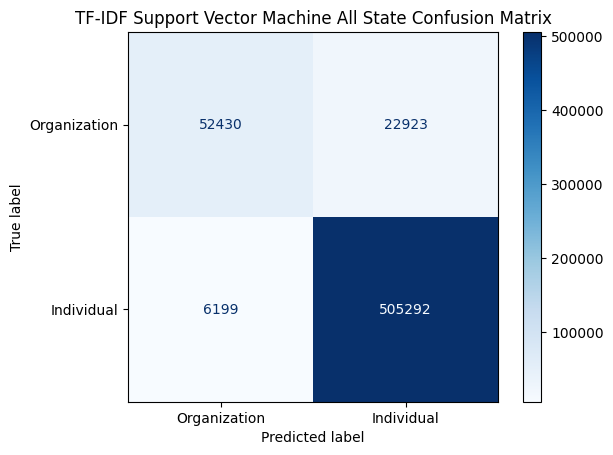

In [5]:
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title('TF-IDF Support Vector Machine All State Confusion Matrix')
plt.savefig('TF-IDF Support Vector Machine All State Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [ ]:
#test_df = pd.read_csv("data\\test.csv")
test_df = pd.read_csv("data\\test-all-states.csv")
#X_test = vectorizer.transform(test_df['full_name'])
X_test = vectorizer.transform(test_df['full_name']) # 'full_name'
y_test = test_df['label']

In [ ]:
# def convert_bool(input_label):
#     '''Converts to numerical encoding'''
#     if input_label == 'Individual':
#         return 1
#     else:
#         return 0
# y_test = np.vectorize(convert_bool)(test_df['transactor_type'])

predicted_y = svc.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, predicted_y) * 100

recall = recall_score(y_test, predicted_y) * 100

precision = precision_score(y_test, predicted_y) * 100

f1 = f1_score(y_test, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()

predicted_y_test = svc.predict(X_test)
print(classification_report(y_test, predicted_y_test))

In [ ]:
cm = confusion_matrix(y_test, predicted_y_test, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title('TF-IDF MI-MN Support Vector Machine Confusion Matrix')
# plt.savefig('TF-IDF MI-MN Support Vector Machine Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [ ]:
misclassified = np.where(y_test != predicted_y_test)[0]
y_test_df = y_test.reset_index().copy()

inverse_names = vectorizer.inverse_transform(X_test)

inverse_names_clean = []
for i in misclassified:
	inverse_names_clean.append(" ".join(list(inverse_names[i])))

print(f"Number of misclassified samples: {len(misclassified)}")
ctr = -1
for i in misclassified:
	ctr+=1
	print(f"ctr: {ctr}")
	print(f"Index: {i}")
	print(f"Full Name: {inverse_names_clean[ctr]}")
	print(f"True Label: {y_test_df.iloc[i]['label']}, Predicted: {predicted_y[i]}")
	print("---")
# Organization = 0
# Individual = 1

In [ ]:
inverse_names[24400]

In [ ]:
# from sklearn.model_selection import GridSearchCV 

# param_grid = {'C': [0.1, 1, 10, 100, 1000], 
# 			'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
# 			'kernel': ['rbf']} 

# grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3) 
 
# grid.fit(X_train, y_train)

In [ ]:
# print(grid.best_params_) 
 
# print(grid.best_estimator_)

In [ ]:
# grid_predictions = grid.predict(y_val) 

# print(classification_report(y_val, grid_predictions))